# Out-of-Sample Validation of Selected Strategies

In this notebook, we evaluate the out-of-sample performance of the top 4 intraday strategies previously selected during the in-sample optimization phase.

The out-of-sample period spans from **January 2024 to April 2026**, and is used to assess the robustness and persistence of the intraday effects identified in the training dataset.

No parameter re-optimization is performed on this period.

In [1]:
import pandas as pd

import sys
import os

sys.path.append(os.path.dirname(os.getcwd()))

from src.backtest import run_backtest, compute_metrics, generate_position, backtest_strategies
from src.plotting import format_results_table, plot_equity_drawdown_grid

In [13]:
# Load EURUSD H1 dataset
df = pd.read_csv("../data/eurusd_h1.csv")

# Load the CSV file containing the top 4 strategies
# previously selected during the optimization phase
top4 = pd.read_csv("../data/top4_strategies.csv")

In [14]:
# Convert the selected strategies into a list of dictionaries
# Each dictionary contains the entry and exit hours
# for a single strategy configuration
strategies = top4[["entry_hour", "exit_hour"]].to_dict("records")

In [15]:
# sanity check
strategies

[{'entry hour': 1, 'exit hour': 2},
 {'entry hour': 0, 'exit hour': 2},
 {'entry hour': 1, 'exit hour': 3},
 {'entry hour': 0, 'exit hour': 3}]

In [16]:
# Convert timestamp column to datetime format
df["time"] = pd.to_datetime(df["time"])

# Set datetime as index for time-series operations
df = df.set_index("time")

In [17]:
# Rename price column to a standard name used in the backtest engine
df = df.rename(columns={"close": "price"})

# Keep only relevant column for strategy/backtest
df = df[["price"]]

# Extract hour of day from datetime index to construct entry/exit trading signals
df["hour"] = df.index.hour

In [18]:
split_date = "2024-01-01"

# Out-of-Sample dataset: all data from the split date onwards
# Used to evaluate the robustness of the strategy on unseen data
df_os = df[df.index >= split_date].copy()

In [19]:
# Quick sanity check of the dataset structure

display(df_os.head())

df_os.info()

,price,hour
time,,
2024-01-02 00:00:00,1.10439,0
2024-01-02 01:00:00,1.10364,1
2024-01-02 02:00:00,1.10381,2
2024-01-02 03:00:00,1.10347,3
2024-01-02 04:00:00,1.10187,4


<class 'pandas.DataFrame'>
DatetimeIndex: 14346 entries, 2024-01-02 00:00:00 to 2026-04-24 10:00:00
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   14346 non-null  float64
 1   hour    14346 non-null  int32  
dtypes: float64(1), int32(1)
memory usage: 280.2 KB


In [20]:
# Run the backtest on all selected strategies
results_df, equity_curves = backtest_strategies(df_os, strategies)

In [21]:
# Display the results table with formatted values
format_results_table(results_df)

,Annualized Return,Annualized Volatility,Max Drawdown,Sharpe Ratio,Calmar Ratio
strategy,,,,,
1-2,3.33%,1.20%,-0.95%,2.77,3.50
0-2,2.99%,1.90%,-2.44%,1.57,1.22
1-3,3.58%,1.73%,-2.77%,2.08,1.30
0-3,3.24%,2.27%,-2.94%,1.43,1.10


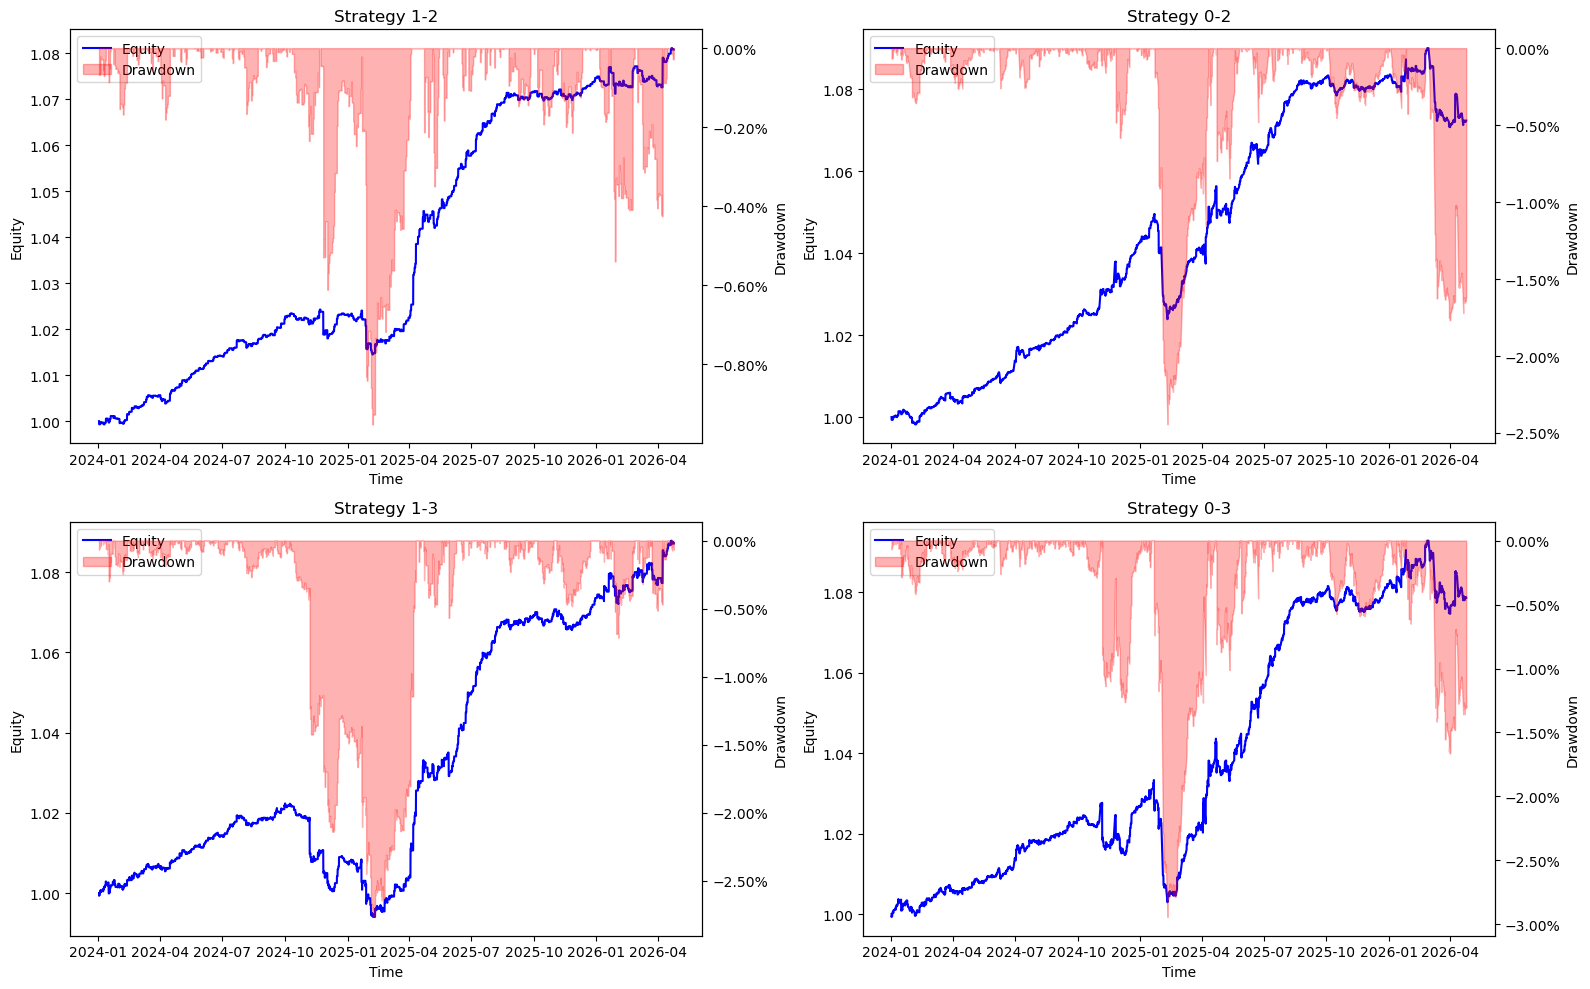

In [22]:
# Plot a grid of equity curves and their corresponding drawdowns
# for all strategies in the equity_curves collection
plot_equity_drawdown_grid(equity_curves)

# Conclusion

The out-of-sample results indicate that the intraday bias identified during the in-sample phase has remained broadly stable over time.

Annualized returns are largely consistent with the in-sample period, showing only a mild variation across strategies:
- Strategy 1-2: 3.49% → 3.33%
- Strategy 0-2: 3.90% → 2.99%
- Strategy 1-3: 3.11% → 3.58%
- Strategy 0-3: 3.52% → 3.24%

Overall, returns remain in a comparable range, suggesting that the underlying effect has not materially decayed out of sample.

Sharpe ratios, as expected, show a more pronounced decrease when moving to unseen data:
- Strategy 1-2: 4.24 → 2.77
- Strategy 0-2: 3.03 → 1.57
- Strategy 1-3: 2.51 → 2.08
- Strategy 0-3: 2.22 → 1.43

This compression in risk-adjusted performance is consistent with the transition from in-sample optimization to out-of-sample validation.

Volatility is slightly higher in the out-of-sample period, which contributes to both the reduced Sharpe ratios and the modest increase in drawdowns. Despite this, all strategies remain profitable and retain positive risk-adjusted performance.

Overall, the results suggest that the intraday pattern is persistent beyond the calibration period, although with naturally lower efficiency in terms of risk-adjusted returns.

The next step is to incorporate transaction costs (commissions and any execution frictions) into the backtest in order to evaluate the net performance of the strategies.

This will provide a more realistic assessment of their profitability and robustness under market conditions closer to live trading.